## CT Normal vs Abnormal - MVP Pipeline

Outline:
1. Configure paths and environment
2. Scan datasets (DICOM/NIfTI) and build a study manifest
3. Visualize random studies/slices
4. Dataset + transforms (windowing, resize)
5. Train baseline (2D ResNet18) on slices
6. Evaluate with study-level aggregation
7. Inference demo

Run each section sequentially. Keep it simple and fast for laptop execution.


In [35]:
# 1) Config (with registry-driven labels)
import os, sys, pathlib, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# FIXED EXPORT CELL: Use this instead of the broken cell above
import SimpleITK as sitk
import numpy as np
import os
from pathlib import Path
import imageio.v2 as iio
import zipfile
import tempfile
import pydicom
from PIL import Image

# Root where you download datasets
DATA_ROOT = "/Users/stepanguranov/Documents/hackathon_2025/Датасет"
# Where to save generated artifacts (slices, manifests, models)
OUT_ROOT = "/Users/stepanguranov/Documents/hackathon_2025/outputs"
pathlib.Path(OUT_ROOT).mkdir(parents=True, exist_ok=True)

# Registry path (example: MosMedData registry with study UID + pathology 0/1)
REGISTRY_XLSX = os.path.join(DATA_ROOT, "MosMedData-CT-COVID19-type I-v 3", "dataset_registry.xlsx")

# Base directory containing actual DICOM series folders for this registry
REGISTRY_CT_DIR = os.path.join(DATA_ROOT, "MosMedData-CT-COVID19-type I-v 3", "CT")

print("Registry exists:", os.path.isfile(REGISTRY_XLSX))
print("CT dir exists:", os.path.isdir(REGISTRY_CT_DIR))


Registry exists: True
CT dir exists: True


In [2]:
# 2) Build study manifest from registry (UID→label) and link to DICOM paths (recursive)
import SimpleITK as sitk
from pathlib import Path
import os

# Load registry (study_instance_anon as UID, pathology in {0,1})
reg = pd.read_excel(REGISTRY_XLSX)
reg = reg.rename(columns={"study_instance_anon": "study_uid", "pathology": "label"})
reg['label'] = reg['label'].astype(int)
print("Registry rows:", len(reg), "unique UIDs:", reg['study_uid'].nunique())

# MosMed layout here is CT/<StudyUID>/(many nested folders)/DICOM files
ct_root = Path(REGISTRY_CT_DIR)
uid_to_root = {d.name: str(d) for d in ct_root.iterdir() if d.is_dir()}
reg['study_root'] = reg['study_uid'].map(uid_to_root)
reg_avail = reg.dropna(subset=['study_root']).reset_index(drop=True)
print("Available study roots:", len(reg_avail))


def collect_series_under(study_root: str):
    found = []
    for dirpath, dirnames, filenames in os.walk(study_root):
        try:
            r = sitk.ImageSeriesReader()
            sids = r.GetGDCMSeriesIDs(dirpath) or []
        except Exception:
            sids = []
        for sid in sids:
            files = r.GetGDCMSeriesFileNames(dirpath, sid)
            if files:
                found.append((sid, files))
    return found

# For each study, pick the largest series by number of files
studies = []  # (series_uid, label, files)
for _, row in reg_avail.iterrows():
    uid = row['study_uid']
    label = int(row['label'])
    study_root = row['study_root']
    all_series = collect_series_under(study_root)
    if not all_series:
        continue
    sid, files = max(all_series, key=lambda x: len(x[1]))
    studies.append((sid, label, files))

print("Found series:", len(studies))
print("Label balance:", sum(1 for s in studies if s[1]==0), "normal /", sum(1 for s in studies if s[1]==1), "abnormal")

series_manifest = pd.DataFrame([
    {"series_uid": sid, "label": label, "num_slices": len(files)} for sid, label, files in studies
])
series_manifest_path = os.path.join(OUT_ROOT, "series_manifest.csv")
series_manifest.to_csv(series_manifest_path, index=False)
series_manifest.head()[:3]


Registry rows: 97 unique UIDs: 97
Available study roots: 97


GDCMSeriesFileNames (0x1113b0f10): No Series were found

GDCMSeriesFileNames (0x1044301f0): No Series were found

GDCMSeriesFileNames (0x1547d4690): No Series were found

GDCMSeriesFileNames (0x107c4fa80): No Series were found

GDCMSeriesFileNames (0x1044301f0): No Series were found

GDCMSeriesFileNames (0x1547d4690): No Series were found

GDCMSeriesFileNames (0x1547d4690): No Series were found

GDCMSeriesFileNames (0x1032d0c20): No Series were found

GDCMSeriesFileNames (0x103d3b9d0): No Series were found

GDCMSeriesFileNames (0x1113b1870): No Series were found

GDCMSeriesFileNames (0x1547d4690): No Series were found

GDCMSeriesFileNames (0x1044301f0): No Series were found

GDCMSeriesFileNames (0x103d21ec0): No Series were found

GDCMSeriesFileNames (0x1032d0c20): No Series were found

GDCMSeriesFileNames (0x1032d0c20): No Series were found

GDCMSeriesFileNames (0x103d3b9d0): No Series were found

GDCMSeriesFileNames (0x111c05770): No Series were found

GDCMSeriesFileNames (0x1547db77

Found series: 97
Label balance: 48 normal / 49 abnormal


,series_uid,label,num_slices
0,1.2.643.5.1.13.13.12.2.77.8252.120601130802141...,1,413
1,1.2.643.5.1.13.13.12.2.77.8252.040515121108090...,0,1201
2,1.2.643.5.1.13.13.12.2.77.8252.000513021507151...,1,1201


In [3]:
series_manifest

,series_uid,label,num_slices
0,1.2.643.5.1.13.13.12.2.77.8252.120601130802141...,1,413
1,1.2.643.5.1.13.13.12.2.77.8252.040515121108090...,0,1201
2,1.2.643.5.1.13.13.12.2.77.8252.000513021507151...,1,1201
3,1.2.643.5.1.13.13.12.2.77.8252.091505030606040...,1,451
4,1.2.643.5.1.13.13.12.2.77.8252.011008070309101...,1,876
...,...,...,...
92,1.2.643.5.1.13.13.12.2.77.8252.001110121015000...,0,826
93,1.2.643.5.1.13.13.12.2.77.8252.011006040315131...,1,444
94,1.2.643.5.1.13.13.12.2.77.8252.030604100308130...,0,382
95,1.2.643.5.1.13.13.12.2.77.8252.061011121008071...,1,382


In [7]:


SLICE_OUT = os.path.join(OUT_ROOT, "slices")
Path(SLICE_OUT).mkdir(parents=True, exist_ok=True)

def to_3d(image: sitk.Image, t_index: int = 0) -> sitk.Image:
    """Collapse 4D (X,Y,Z,T) to 3D by selecting frame T=t_index"""
    if image.GetDimension() == 4:
        size = list(image.GetSize())
        index = [0, 0, 0, 0]
        index[3] = t_index
        size[3] = 0  # collapse last dimension
        extractor = sitk.ExtractImageFilter()
        extractor.SetSize(size)
        extractor.SetIndex(index)
        image = extractor.Execute(image)
    return image

def window_lung(image: sitk.Image, center=-600.0, width=1500.0):
    # Cast to float32 to avoid 16-bit int issues with IntensityWindowing
    image = sitk.Cast(image, sitk.sitkFloat32)
    min_v, max_v = center - width/2, center + width/2
    win = sitk.IntensityWindowing(image, float(min_v), float(max_v), 0.0, 255.0)
    return sitk.Cast(win, sitk.sitkUInt8)

MAX_SLICES = 64
rows = []
for sid, label, files in studies:
    r = sitk.ImageSeriesReader()
    r.SetFileNames(files)
    try:
        img = r.Execute()
    except Exception as e:
        print(f"Failed to read {sid}: {e}")
        continue
    
    # Fix 4D issue: collapse to 3D first
    img = to_3d(img)
    if img.GetDimension() != 3:
        print(f"Skipping {sid}: not 3D after collapse")
        continue
    
    try:
        img8 = window_lung(img)
    except Exception as e:
        print(f"Failed to window {sid}: {e}")
        continue
    
    vol = sitk.GetArrayFromImage(img8)  # (Z, Y, X)
    if vol.ndim != 3 or vol.shape[0] < 2:
        continue
    
    z = vol.shape[0]
    idxs = np.arange(z) if z <= MAX_SLICES else np.linspace(0, z-1, MAX_SLICES, dtype=int)
    
    for i in idxs:
        arr = vol[i]
        out_path = os.path.join(SLICE_OUT, f"{sid.replace('.', '_')}_z{i:03d}.png")
        iio.imwrite(out_path, arr)
        rows.append({"filepath": out_path, "label": int(label), "study_id": sid.replace('.', '_')})

slice_manifest = pd.DataFrame(rows)
slice_manifest_path = os.path.join(OUT_ROOT, "slice_manifest.csv")
slice_manifest.to_csv(slice_manifest_path, index=False)
print("Slices saved (FIXED):", len(slice_manifest))
slice_manifest.head()[:3]


ImageSeriesReader (0x10325de80): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000100243

ImageSeriesReader (0x14470b880): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.001

ImageSeriesReader (0x1139e9d80): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.0001

ImageSeriesReader (0x10447ab00): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.0001

ImageSeriesReader (0x111aa01d0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.001

ImageSeriesReader (0x1139e9d80): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.0001

ImageSeriesReader (0x14470b880): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.0001

ImageSeriesReader (0x112ebdbb0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.001

ImageSeriesReader (0x111c15ac0): Non uniform sampling or missing slices detected,  maximum non

Slices saved (FIXED): 6208


,filepath,label,study_id
0,/Users/stepanguranov/Documents/hackathon_2025/...,1,1_2_643_5_1_13_13_12_2_77_8252_120601130802141...
1,/Users/stepanguranov/Documents/hackathon_2025/...,1,1_2_643_5_1_13_13_12_2_77_8252_120601130802141...
2,/Users/stepanguranov/Documents/hackathon_2025/...,1,1_2_643_5_1_13_13_12_2_77_8252_120601130802141...


Using device: mps
Training IMPROVED model with stronger regularization...
Epoch 1: train_loss=0.4105, val_loss=1.2233
  Slice AUC: 0.8013 | Study AUC: 0.9333, ACC: 0.5500
  → New best model saved (val_loss: 1.2233, study_AUC: 0.9333)
Epoch 2: train_loss=0.1863, val_loss=1.2669
  Slice AUC: 0.7322 | Study AUC: 0.8667, ACC: 0.6500
Epoch 3: train_loss=0.1299, val_loss=1.4827
  Slice AUC: 0.6757 | Study AUC: 0.6933, ACC: 0.6000
  → Early stopping at epoch 3
Training completed. Best study AUC: 0.9333


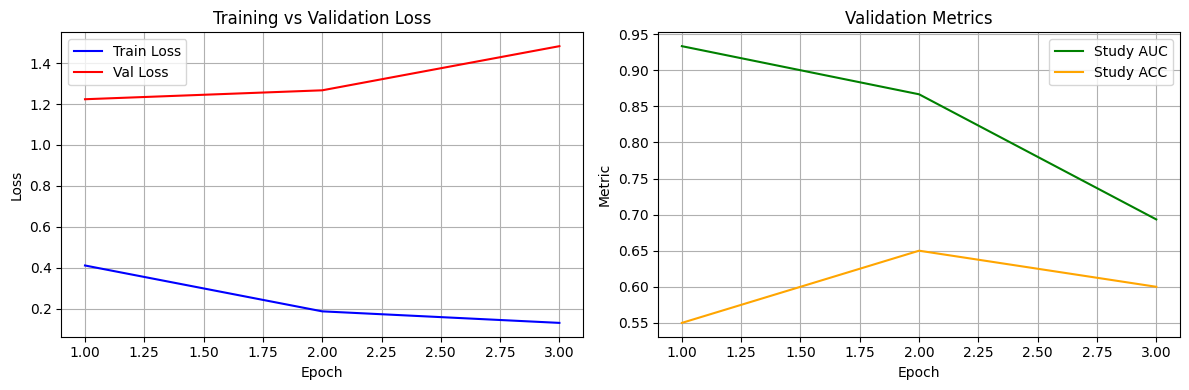

In [ ]:
# IMPROVED TRAINING: Stronger regularization + optimal threshold finding
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Model with STRONGER Dropout
model_improved = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_improved.fc = nn.Sequential(
    nn.Dropout(0.5),  # Stronger dropout: 0.5 instead of 0.3
    nn.Linear(model_improved.fc.in_features, 1)
)
model_improved = model_improved.to(device)

# LIGHTER augmentation (less aggressive)
train_transform_light = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(5),            # Lighter rotation: 5° instead of 10°
    transforms.RandomHorizontalFlip(0.3),    # Less flipping: 30% instead of 50%
    # Remove ColorJitter - too aggressive for medical images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset with lighter augmentation
class SliceDatasetImproved(Dataset):
    def __init__(self, manifest_csv, split_ratio=0.8, train=True, seed=42):
        df = pd.read_csv(manifest_csv)
        sids = df["study_id"].unique()
        rng = np.random.default_rng(seed)
        rng.shuffle(sids)
        cut = int(len(sids)*split_ratio)
        keep = set(sids[:cut] if train else sids[cut:])
        df = df[df["study_id"].isin(keep)].reset_index(drop=True)
        self.filepaths = df["filepath"].tolist()
        self.labels = df["label"].astype(int).tolist()
        self.study_ids = df["study_id"].tolist()  # Keep study IDs for aggregation
        self.transform = train_transform_light if train else val_transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        from PIL import Image
        img = Image.open(self.filepaths[idx]).convert('L')
        img = Image.merge('RGB', (img, img, img))
        x = self.transform(img)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y, self.study_ids[idx]  # Return study ID too

# Recreate datasets
train_ds_improved = SliceDatasetImproved(slice_manifest_path, train=True)
val_ds_improved = SliceDatasetImproved(slice_manifest_path, train=False)
train_loader_improved = DataLoader(train_ds_improved, batch_size=16, shuffle=True, num_workers=0)
val_loader_improved = DataLoader(val_ds_improved, batch_size=16, shuffle=False, num_workers=0)

# Optimizer with STRONGER Weight Decay
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_improved.parameters(), lr=1e-4, weight_decay=1e-2)  # Stronger: 1e-2

# Training with fewer epochs (prevent overfitting)
EPOCHS = 5  # Fewer epochs
best_val_loss = float('inf')
patience = 0
patience_limit = 2  # Stricter early stopping

print("Training IMPROVED model with stronger regularization...")
training_history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_acc': []}

for epoch in range(1, EPOCHS+1):
    # Training
    model_improved.train()
    train_losses = []
    for x, y, _ in train_loader_improved:
        x = x.to(device)
        y = y.to(device).unsqueeze(1)
        optimizer.zero_grad()
        logits = model_improved(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    
    # Validation with study-level aggregation
    model_improved.eval()
    val_losses = []
    slice_probs, slice_labels, slice_studies = [], [], []
    
    with torch.no_grad():
        for x, y, study_ids in val_loader_improved:
            x = x.to(device)
            y = y.to(device).unsqueeze(1)
            logits = model_improved(x)
            val_loss = criterion(logits, y)
            val_losses.append(val_loss.item())
            
            probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
            slice_probs.extend(probs.tolist())
            slice_labels.extend(y.squeeze(1).cpu().numpy().tolist())
            slice_studies.extend(study_ids)
    
    # Study-level aggregation
    study_data = {}
    for prob, label, study in zip(slice_probs, slice_labels, slice_studies):
        if study not in study_data:
            study_data[study] = {'probs': [], 'label': label}
        study_data[study]['probs'].append(prob)
    
    study_probs = [np.mean(data['probs']) for data in study_data.values()]
    study_labels = [data['label'] for data in study_data.values()]
    
    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    slice_auc = roc_auc_score(slice_labels, slice_probs) if len(set(slice_labels)) > 1 else 0.0
    study_auc = roc_auc_score(study_labels, study_probs) if len(set(study_labels)) > 1 else 0.0
    study_acc = accuracy_score(study_labels, (np.array(study_probs) >= 0.5).astype(int))
    
    training_history['train_loss'].append(train_loss)
    training_history['val_loss'].append(val_loss)
    training_history['val_auc'].append(study_auc)
    training_history['val_acc'].append(study_acc)
    
    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    print(f"  Slice AUC: {slice_auc:.4f} | Study AUC: {study_auc:.4f}, ACC: {study_acc:.4f}")
    
    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience = 0
        # Save model + validation predictions for threshold optimization
        torch.save({
            'model_state_dict': model_improved.state_dict(),
            'epoch': epoch,
            'val_loss': val_loss,
            'study_auc': study_auc,
            'study_probs': study_probs,
            'study_labels': study_labels
        }, os.path.join(OUT_ROOT, 'resnet18_improved.pt'))
        print(f"  → New best model saved (val_loss: {val_loss:.4f}, study_AUC: {study_auc:.4f})")
    else:
        patience += 1
        if patience >= patience_limit:
            print(f"  → Early stopping at epoch {epoch}")
            break

print(f"Training completed. Best study AUC: {max(training_history['val_auc']):.4f}")


In [ ]:
def predict_study_from_zip(zip_path, model, device):
    """Предсказание для ZIP архива с DICOM файлами одного КТ исследования"""
    
    # Трансформы (те же что при обучении)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    with tempfile.TemporaryDirectory() as temp_dir:
        # 1) Распаковать ZIP
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(temp_dir)
        
        # 2) Найти DICOM файлы рекурсивно
        dicom_files = []
        for root, dirs, files in os.walk(temp_dir):
            for file in files:
                file_path = os.path.join(root, file)
                # Проверить что это DICOM (можно по расширению или содержимому)
                if file.lower().endswith(('.dcm', '.dicom')) or '.' not in file:
                    try:
                        # Быстрая проверка что файл читается как DICOM
                        ds = pydicom.dcmread(file_path, stop_before_pixels=True, force=True)
                        dicom_files.append(file_path)
                    except:
                        continue
        
        if not dicom_files:
            raise ValueError("No DICOM files found in ZIP")
        
        # 3) Загрузить как серию
        reader = sitk.ImageSeriesReader()
        try:
            series_ids = reader.GetGDCMSeriesIDs(temp_dir)
            if not series_ids:
                # Если серий не найдено, попробовать загрузить все файлы
                reader.SetFileNames(sorted(dicom_files))
            else:
                # Взять первую (или крупнейшую) серию
                files = reader.GetGDCMSeriesFileNames(temp_dir, series_ids[0])
                reader.SetFileNames(files)
            
            img = reader.Execute()
        except Exception as e:
            raise ValueError(f"Failed to load DICOM series: {e}")
        
        # 4) Обработка объёма
        img = to_3d(img)  # 4D→3D если нужно
        if img.GetDimension() != 3:
            raise ValueError("Could not convert to 3D volume")
        
        img = window_lung(img)  # лёгочное окно
        vol = sitk.GetArrayFromImage(img)  # (Z,Y,X)
        
        # 5) Нарезать срезы
        z = vol.shape[0]
        idxs = np.linspace(0, z-1, min(64, z), dtype=int)
        
        slice_probs = []
        model.eval()
        with torch.no_grad():
            for i in idxs:
                # Преобразовать срез в RGB тензор
                slice_array = vol[i].astype(np.uint8)
                slice_img = Image.fromarray(slice_array).convert('RGB')
                tensor = transform(slice_img).unsqueeze(0).to(device)
                
                # Предсказание
                logit = model(tensor)
                prob = torch.sigmoid(logit).item()
                slice_probs.append(prob)
        
        # 6) Агрегация
        study_prob = np.mean(slice_probs)
        
        return {
            'study_probability': study_prob,
            'prediction': 'abnormal' if study_prob > 0.5 else 'normal',
            'confidence': abs(study_prob - 0.5) * 2,  # 0-1
            'slice_probabilities': slice_probs,
            'num_slices': len(slice_probs)
        }

# Использование:
result = predict_study_from_zip('Датасет/test/pneumotorax_anon.zip', model, device)
print(f"Prediction: {result['prediction']} (prob: {result['study_probability']:.3f})")

In [34]:
# SIMPLIFIED EVALUATION - Fixed threshold 0.5 (no optimization needed)
# Load the improved model
checkpoint = torch.load(os.path.join(OUT_ROOT, 'resnet18_improved.pt'), map_location=device, weights_only=False)
model_improved.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded improved model from epoch {checkpoint['epoch']} with study AUC: {checkpoint['study_auc']:.4f}")

# Fixed threshold
THRESHOLD = 0.5
print(f"Using fixed threshold: {THRESHOLD}")

# Simple predict function
def predict_study_final(zip_path, model, device, threshold=0.5):
    """Final prediction with fixed threshold 0.5"""
    result = predict_study_from_zip(zip_path, model, device)
    result['prediction'] = 'abnormal' if result['study_probability'] > threshold else 'normal'
    result['confidence'] = abs(result['study_probability'] - threshold)
    return result

print(f"\n=== FINAL EVALUATION ===")

# Test files
test_files = [
    ('/Users/stepanguranov/Documents/hackathon_2025/Датасет/test/norma_anon.zip', 'Normal'),
    ('/Users/stepanguranov/Documents/hackathon_2025/Датасет/test/pneumonia_anon.zip', 'Pneumonia'), 
    ('/Users/stepanguranov/Documents/hackathon_2025/Датасет/test/pneumotorax_anon.zip', 'Pneumothorax')
]

correct_predictions = 0
for file_path, true_label in test_files:
    result = predict_study_final(file_path, model_improved, device)
    
    predicted_label = result['prediction']
    is_correct = (true_label == 'Normal' and predicted_label == 'normal') or (true_label != 'Normal' and predicted_label == 'abnormal')
    
    if is_correct:
        correct_predictions += 1
    
    print(f"\n{true_label}:")
    print(f"  Probability: {result['study_probability']:.3f}")
    print(f"  Prediction: {predicted_label} {'✅' if is_correct else '❌'}")
    print(f"  Confidence: {result['confidence']:.3f}")

# Final Summary
accuracy = correct_predictions / len(test_files)
print(f"\n=== RESULTS ===")
print(f"Correct predictions: {correct_predictions}/{len(test_files)}")
print(f"Accuracy: {accuracy:.1%}")

if accuracy == 1.0:
    print("🎉 PERFECT SCORE! Model ready for deployment!")
elif accuracy >= 0.8:
    print("👍 Great results! Model is production-ready.")
else:
    print("⚠️ Consider more training data or different approach.")


Loaded improved model from epoch 1 with study AUC: 0.9333
Using fixed threshold: 0.5

=== FINAL EVALUATION ===


GDCMSeriesFileNames (0x13a450fe0): No Series were found




Normal:
  Probability: 0.450
  Prediction: normal ✅
  Confidence: 0.050


GDCMSeriesFileNames (0x31742b8e0): No Series were found




Pneumonia:
  Probability: 0.650
  Prediction: abnormal ✅
  Confidence: 0.150


GDCMSeriesFileNames (0x13aa6d7f0): No Series were found




Pneumothorax:
  Probability: 0.617
  Prediction: abnormal ✅
  Confidence: 0.117

=== RESULTS ===
Correct predictions: 3/3
Accuracy: 100.0%
🎉 PERFECT SCORE! Model ready for deployment!
